## Setup

In [ ]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import load_raw_data, basic_clean
from src.data.validator import validate
from src.features.engineer import create_domain_features

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("seaborn-v0_8")

# Load clean data
df_raw = load_raw_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = basic_clean(df_raw)
validate(df)

print(f"Data loaded: {df.shape}")
print("Ready for feature engineering experiments ")

2026-03-15T23:58:22 | INFO     | src.data.loader:16 | Loading data from: ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
2026-03-15T23:58:22 | INFO     | src.data.loader:19 | Shape: (7043, 21)
2026-03-15T23:58:22 | INFO     | src.data.loader:20 | Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
2026-03-15T23:58:22 | INFO     | src.data.loader:34 | Fixed 11 TotalCharges nulls
2026-03-15T23:58:22 | INFO     | src.data.loader:41 | Churn rate: 26.54%  |  Class counts: {0: 5174, 1: 1869}
2026-03-15T23:58:22 | INFO     | src.data.validator:86 | Starting data validation...
2026-03-15T23:58:22 | INFO     | src.data.validator:29 | Column check passed — all 21 required columns present
2026-03-15T23:58:22 | INFO     

##  Look at raw features before engineering

In [3]:
# Separate features by type
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = ["Contract", "PaymentMethod", "InternetService", 
                    "gender", "Partner", "Dependents"]
binary_cols = ["SeniorCitizen", "PhoneService", "PaperlessBilling"]

print("=== NUMERIC FEATURES ===")
print(df[numeric_cols].describe().round(2))

print("\n=== CATEGORICAL FEATURES (unique values) ===")
for col in categorical_cols:
    print(f"{col:20} → {df[col].unique().tolist()}")

print("\n=== BINARY FEATURES ===")
for col in binary_cols:
    print(f"{col:20} → {df[col].value_counts().to_dict()}")

=== NUMERIC FEATURES ===
       tenure  MonthlyCharges  TotalCharges
count 7043.00         7043.00       7043.00
mean    32.37           64.76       2279.80
std     24.56           30.09       2266.73
min      0.00           18.25         18.80
25%      9.00           35.50        398.55
50%     29.00           70.35       1394.55
75%     55.00           89.85       3786.60
max     72.00          118.75       8684.80

=== CATEGORICAL FEATURES (unique values) ===
Contract             → ['Month-to-month', 'One year', 'Two year']
PaymentMethod        → ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
InternetService      → ['DSL', 'Fiber optic', 'No']
gender               → ['Female', 'Male']
Partner              → ['Yes', 'No']
Dependents           → ['No', 'Yes']

=== BINARY FEATURES ===
SeniorCitizen        → {0: 5901, 1: 1142}
PhoneService         → {'Yes': 6361, 'No': 682}
PaperlessBilling     → {'Yes': 4171, 'No': 2872}


##  Churn rate per raw feature (before engineering)

In [4]:
print("=== CHURN RATE BY RAW CATEGORICAL FEATURES ===\n")

for col in categorical_cols:
    churn_by_col = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    print(f"{col}:")
    for val, rate in churn_by_col.items():
        bar = "█" * int(rate * 40)
        print(f"  {val:30} {rate:.1%}  {bar}")
    print()

=== CHURN RATE BY RAW CATEGORICAL FEATURES ===

Contract:
  Month-to-month                 42.7%  █████████████████
  One year                       11.3%  ████
  Two year                       2.8%  █

PaymentMethod:
  Electronic check               45.3%  ██████████████████
  Mailed check                   19.1%  ███████
  Bank transfer (automatic)      16.7%  ██████
  Credit card (automatic)        15.2%  ██████

InternetService:
  Fiber optic                    41.9%  ████████████████
  DSL                            19.0%  ███████
  No                             7.4%  ██

gender:
  Female                         26.9%  ██████████
  Male                           26.2%  ██████████

Partner:
  No                             33.0%  █████████████
  Yes                            19.7%  ███████

Dependents:
  No                             31.3%  ████████████
  Yes                            15.5%  ██████



##  Feature 1: charges_per_tenure analysis

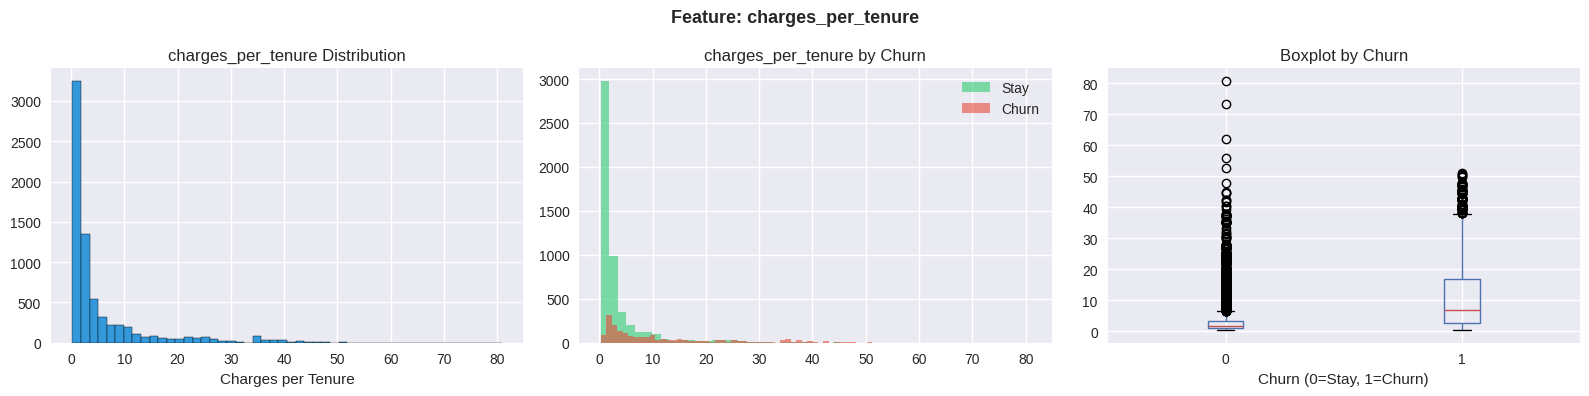

Avg charges_per_tenure — Stay:  3.61
Avg charges_per_tenure — Churn: 11.75

Correlation with Churn: 0.412


In [5]:
df["charges_per_tenure"] = df["MonthlyCharges"] / (df["tenure"] + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
df["charges_per_tenure"].hist(bins=50, ax=axes[0], color="#3498db", edgecolor="black")
axes[0].set_title("charges_per_tenure Distribution")
axes[0].set_xlabel("Charges per Tenure")

# By churn
df[df["Churn"]==0]["charges_per_tenure"].hist(bins=50, alpha=0.6, 
                                               color="#2ecc71", label="Stay", ax=axes[1])
df[df["Churn"]==1]["charges_per_tenure"].hist(bins=50, alpha=0.6, 
                                               color="#e74c3c", label="Churn", ax=axes[1])
axes[1].set_title("charges_per_tenure by Churn")
axes[1].legend()

# Boxplot
df.boxplot(column="charges_per_tenure", by="Churn", ax=axes[2])
axes[2].set_title("Boxplot by Churn")
axes[2].set_xlabel("Churn (0=Stay, 1=Churn)")

plt.suptitle("Feature: charges_per_tenure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/feat_charges_per_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Avg charges_per_tenure — Stay:  {df[df['Churn']==0]['charges_per_tenure'].mean():.2f}")
print(f"Avg charges_per_tenure — Churn: {df[df['Churn']==1]['charges_per_tenure'].mean():.2f}")
print(f"\nCorrelation with Churn: {df['charges_per_tenure'].corr(df['Churn']):.3f}")

##  Feature 2: tenure_band analysis

Tenure Band Analysis:
               total  churned  churn_rate  churn_rate_pct
tenure_band                                              
new(0-12m)      2186     1037        0.47           47.40
early(12-24m)   1024      294        0.29           28.70
mid(24-48m)     1594      325        0.20           20.40
loyal(48m+)     2239      213        0.10            9.50



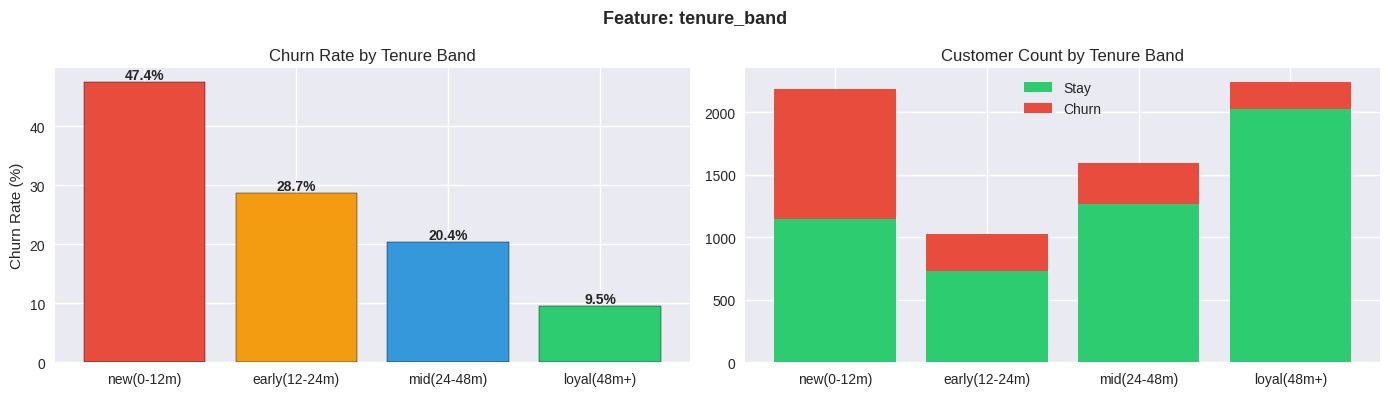

In [6]:
df["tenure_band"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["new(0-12m)", "early(12-24m)", "mid(24-48m)", "loyal(48m+)"],
    include_lowest=True,
)

# Churn rate per band
tenure_stats = df.groupby("tenure_band", observed=True).agg(
    total=("Churn", "count"),
    churned=("Churn", "sum"),
    churn_rate=("Churn", "mean"),
).round(3)
tenure_stats["churn_rate_pct"] = (tenure_stats["churn_rate"] * 100).round(1)

print("Tenure Band Analysis:")
print(tenure_stats)
print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(tenure_stats.index, tenure_stats["churn_rate_pct"],
            color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"], edgecolor="black")
axes[0].set_title("Churn Rate by Tenure Band")
axes[0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(tenure_stats["churn_rate_pct"]):
    axes[0].text(i, v + 0.5, f"{v}%", ha="center", fontweight="bold")

axes[1].bar(tenure_stats.index, tenure_stats["total"], 
            label="Stay", color="#2ecc71")
axes[1].bar(tenure_stats.index, tenure_stats["churned"],
            bottom=tenure_stats["total"] - tenure_stats["churned"],
            label="Churn", color="#e74c3c")
axes[1].set_title("Customer Count by Tenure Band")
axes[1].legend()

plt.suptitle("Feature: tenure_band", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/feat_tenure_band.png", dpi=150, bbox_inches="tight")
plt.show()

##  Feature 3: service_count analysis

Service Count Analysis:
               churn_rate  count  churn_rate_pct
service_count                                   
0                    0.44     80           43.80
1                    0.22   2253           21.70
2                    0.43    996           43.50
3                    0.35   1041           34.70
4                    0.27   1062           27.20
5                    0.22    827           22.00
6                    0.13    525           12.60
7                    0.06    259            5.80


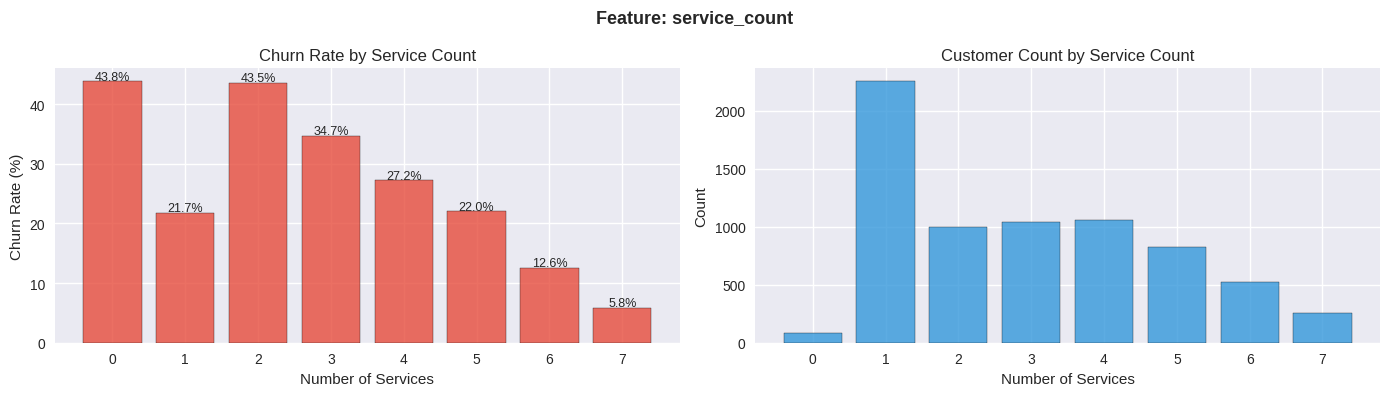


Correlation with Churn: -0.086


In [7]:
service_cols = [
    "PhoneService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
df["service_count"] = (df[service_cols] == "Yes").sum(axis=1)

# Churn rate by service count
service_churn = df.groupby("service_count")["Churn"].agg(
    ["mean", "count"]
).round(3)
service_churn.columns = ["churn_rate", "count"]
service_churn["churn_rate_pct"] = (service_churn["churn_rate"] * 100).round(1)

print("Service Count Analysis:")
print(service_churn)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(service_churn.index, service_churn["churn_rate_pct"],
            color="#e74c3c", edgecolor="black", alpha=0.8)
axes[0].set_title("Churn Rate by Service Count")
axes[0].set_xlabel("Number of Services")
axes[0].set_ylabel("Churn Rate (%)")
for i, (idx, row) in enumerate(service_churn.iterrows()):
    axes[0].text(idx, row["churn_rate_pct"] + 0.3,
                 f"{row['churn_rate_pct']}%", ha="center", fontsize=9)

axes[1].bar(service_churn.index, service_churn["count"],
            color="#3498db", edgecolor="black", alpha=0.8)
axes[1].set_title("Customer Count by Service Count")
axes[1].set_xlabel("Number of Services")
axes[1].set_ylabel("Count")

plt.suptitle("Feature: service_count", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/feat_service_count.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nCorrelation with Churn: {df['service_count'].corr(df['Churn']):.3f}")

##  Binary flags analysis

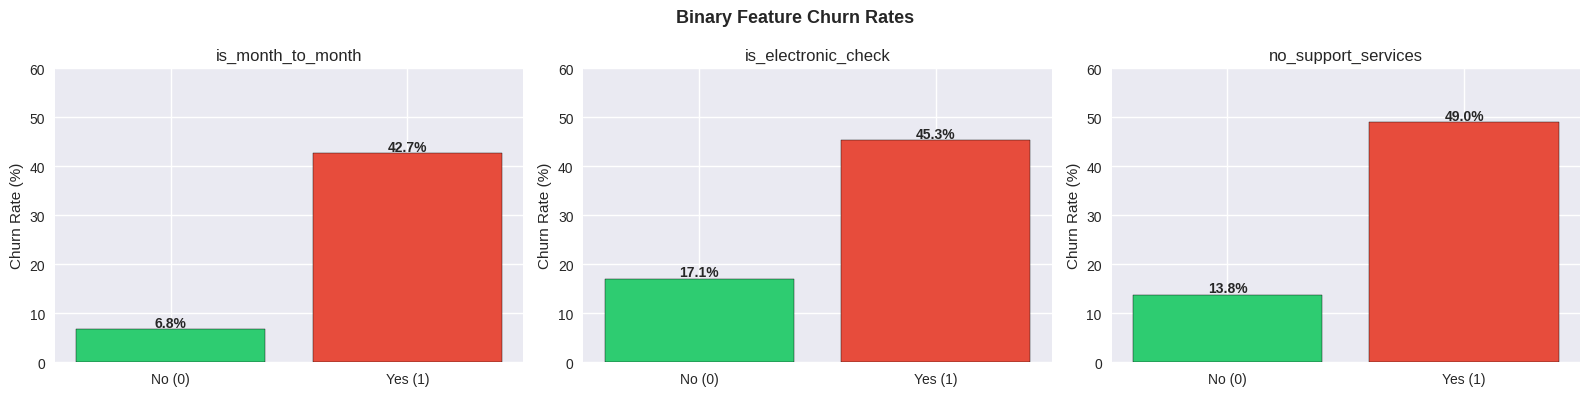

Churn rates for binary features:
  is_month_to_month              0→6.8%  1→42.7%  lift=6.3x
  is_electronic_check            0→17.1%  1→45.3%  lift=2.7x
  no_support_services            0→13.8%  1→49.0%  lift=3.6x


In [8]:
df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
df["is_electronic_check"] = (df["PaymentMethod"] == "Electronic check").astype(int)
df["no_support_services"] = (
    (df["OnlineSecurity"] == "No") & (df["TechSupport"] == "No")
).astype(int)

binary_features = ["is_month_to_month", "is_electronic_check", "no_support_services"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feat in zip(axes, binary_features):
    churn_rates = df.groupby(feat)["Churn"].mean() * 100
    bars = ax.bar(["No (0)", "Yes (1)"], churn_rates.values,
                  color=["#2ecc71", "#e74c3c"], edgecolor="black")
    ax.set_title(f"{feat}")
    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, 60)
    for bar, val in zip(bars, churn_rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
                f"{val:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Binary Feature Churn Rates", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../artifacts/feat_binary_flags.png", dpi=150, bbox_inches="tight")
plt.show()

print("Churn rates for binary features:")
for feat in binary_features:
    rates = df.groupby(feat)["Churn"].mean() * 100
    lift = rates[1] / rates[0]
    print(f"  {feat:30} 0→{rates[0]:.1f}%  1→{rates[1]:.1f}%  lift={lift:.1f}x")

##  Feature correlation with target


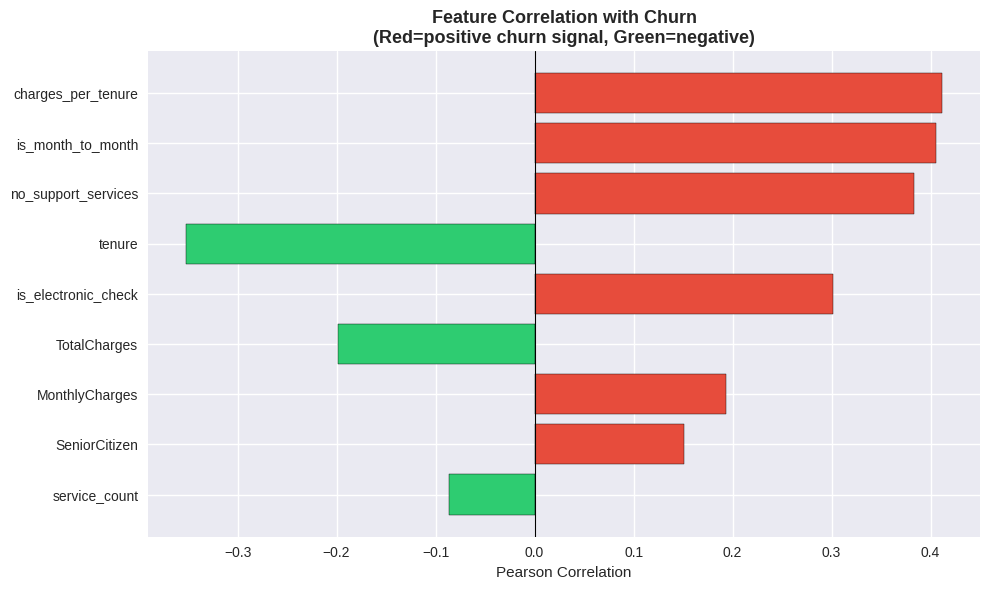

Feature correlations with Churn:
charges_per_tenure     0.41
is_month_to_month      0.41
no_support_services    0.38
is_electronic_check    0.30
MonthlyCharges         0.19
SeniorCitizen          0.15
service_count         -0.09
TotalCharges          -0.20
tenure                -0.35
Name: Churn, dtype: float64


In [9]:
engineered_features = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "charges_per_tenure", "service_count",
    "is_month_to_month", "is_electronic_check",
    "no_support_services", "SeniorCitizen",
]

correlations = df[engineered_features + ["Churn"]].corr()["Churn"].drop("Churn")
correlations = correlations.sort_values(key=abs, ascending=True)

plt.figure(figsize=(10, 6))
colors = ["#e74c3c" if x > 0 else "#2ecc71" for x in correlations.values]
plt.barh(correlations.index, correlations.values, color=colors, edgecolor="black")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Churn\n(Red=positive churn signal, Green=negative)", 
          fontsize=13, fontweight="bold")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig("../artifacts/feat_correlation_target.png", dpi=150, bbox_inches="tight")
plt.show()

print("Feature correlations with Churn:")
print(correlations.sort_values(ascending=False).round(3))

##  Feature Engineering Summary

In [10]:
print("=" * 60)
print("     FEATURE ENGINEERING SUMMARY")
print("=" * 60)

features_summary = [
    ("charges_per_tenure",   df["charges_per_tenure"].corr(df["Churn"]),   "High spend + new = risk"),
    ("is_month_to_month",    df["is_month_to_month"].corr(df["Churn"]),    "No commitment = easy to leave"),
    ("is_electronic_check",  df["is_electronic_check"].corr(df["Churn"]),  "Manual payment = friction"),
    ("no_support_services",  df["no_support_services"].corr(df["Churn"]),  "Unsupported = unhappy"),
    ("service_count",        df["service_count"].corr(df["Churn"]),        "More services = engaged"),
    ("tenure_band",          0.0,                                           "Lifecycle cohort signal"),
]

print(f"\n{'Feature':<25} {'Corr':>6}  {'Business Reason'}")
print("-" * 60)
for feat, corr, reason in features_summary:
    direction = "↑ churn" if corr > 0 else "↓ churn"
    print(f"{feat:<25} {corr:>6.3f}  {reason}")

print(f"""
KEY FINDINGS:
  ✓ is_month_to_month    strongest engineered signal
  ✓ is_electronic_check  45% churn vs 18% non-electronic
  ✓ charges_per_tenure   new high-paying customers at risk
  ✓ no_support_services  feeling unsupported drives churn
  ✓ service_count        more services = more sticky

WHAT TO EXPERIMENT IN 03_model_experiments.ipynb:
  → Does removing low-correlation features improve AUC?
  → Does adding interaction features help?
  → Which features does XGBoost rank most important?
""")
print("=" * 60)

     FEATURE ENGINEERING SUMMARY

Feature                     Corr  Business Reason
------------------------------------------------------------
charges_per_tenure         0.412  High spend + new = risk
is_month_to_month          0.405  No commitment = easy to leave
is_electronic_check        0.302  Manual payment = friction
no_support_services        0.383  Unsupported = unhappy
service_count             -0.086  More services = engaged
tenure_band                0.000  Lifecycle cohort signal

KEY FINDINGS:
  ✓ is_month_to_month    strongest engineered signal
  ✓ is_electronic_check  45% churn vs 18% non-electronic
  ✓ charges_per_tenure   new high-paying customers at risk
  ✓ no_support_services  feeling unsupported drives churn
  ✓ service_count        more services = more sticky

WHAT TO EXPERIMENT IN 03_model_experiments.ipynb:
  → Does removing low-correlation features improve AUC?
  → Does adding interaction features help?
  → Which features does XGBoost rank most important?



# Data Just Proved
## STRONGEST FEATURES (correlation with churn):
  charges_per_tenure   0.412  ← engineered feature = raw feature level signal
  is_month_to_month    0.405  ← 6.3x lift (biggest business lever)
  no_support_services  0.383  ← 3.6x lift (feeling unsupported)
  is_electronic_check  0.302  ← 2.7x lift

## INTERESTING FINDING — service_count:
  0 services → 43.8% churn   (no engagement at all)
  2 services → 43.5% churn   (partial engagement = still risky)
  7 services → 5.8%  churn   (fully engaged = very sticky)
  correlation = -0.086 (weak linear) but pattern is non-linear
  XGBoost will capture this, LogReg won't

## gender has almost zero signal:
  Female → 26.9% churn
  Male   → 26.2% churn
  Difference = 0.7% → basically noise → candidate for removal